In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [32]:
df = pd.read_csv("Facebook Spam Dataset.csv")
print(df.head())

   profile id  #friends  #following  #community  age  #postshared  #urlshared  \
0           1        39         300         907  200         1000         850   
1           2       150         350          30  300          300         100   
2           3       300         450          50  465          500         150   
3           4        25         110         660  350         2050        2000   
4           5        24         100         150  800          950        1000   

   #photos/videos    fpurls  fpphotos/videos  avgcomment/post  likes/post  \
0             922  0.490000         0.550000             0.56        0.47   
1             290  0.330000         0.960000             0.50        1.20   
2             450  0.200000         0.840000             0.40        1.50   
3            2050  0.975610         1.000000             0.70        0.30   
4             900  1.052632         0.947368             0.66        0.50   

   tags/post  #tags/post  Label  
0         40    

In [33]:
print(df.shape)
print(df.info())

(600, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   profile id       600 non-null    int64  
 1   #friends         600 non-null    int64  
 2   #following       600 non-null    int64  
 3   #community       600 non-null    int64  
 4   age              600 non-null    int64  
 5   #postshared      600 non-null    int64  
 6   #urlshared       600 non-null    int64  
 7   #photos/videos   600 non-null    int64  
 8   fpurls           598 non-null    float64
 9   fpphotos/videos  600 non-null    float64
 10  avgcomment/post  600 non-null    float64
 11  likes/post       600 non-null    float64
 12  tags/post        600 non-null    int64  
 13  #tags/post       600 non-null    int64  
 14  Label            600 non-null    int64  
dtypes: float64(4), int64(11)
memory usage: 70.4 KB
None


In [34]:
df = df.drop(columns=["profile id"])

In [35]:
df.isnull().sum()

,0
#friends,0
#following,0
#community,0
age,0
#postshared,0
#urlshared,0
#photos/videos,0
fpurls,2
fpphotos/videos,0
avgcomment/post,0


In [36]:
df.fillna(df.mean(), inplace=True)

Exploratory Data Analysis (EDA)

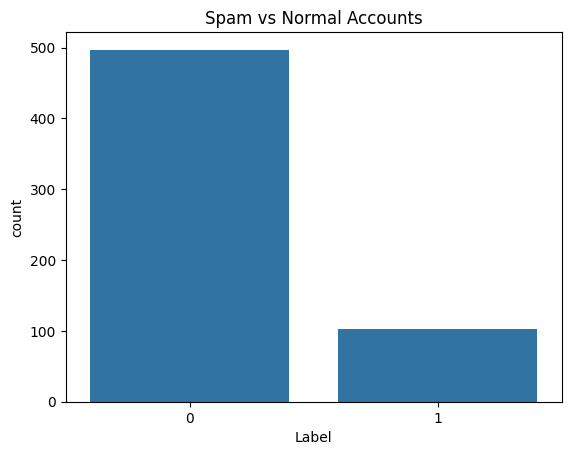

In [37]:
sns.countplot(x='Label', data=df)
plt.title("Spam vs Normal Accounts")
plt.show()

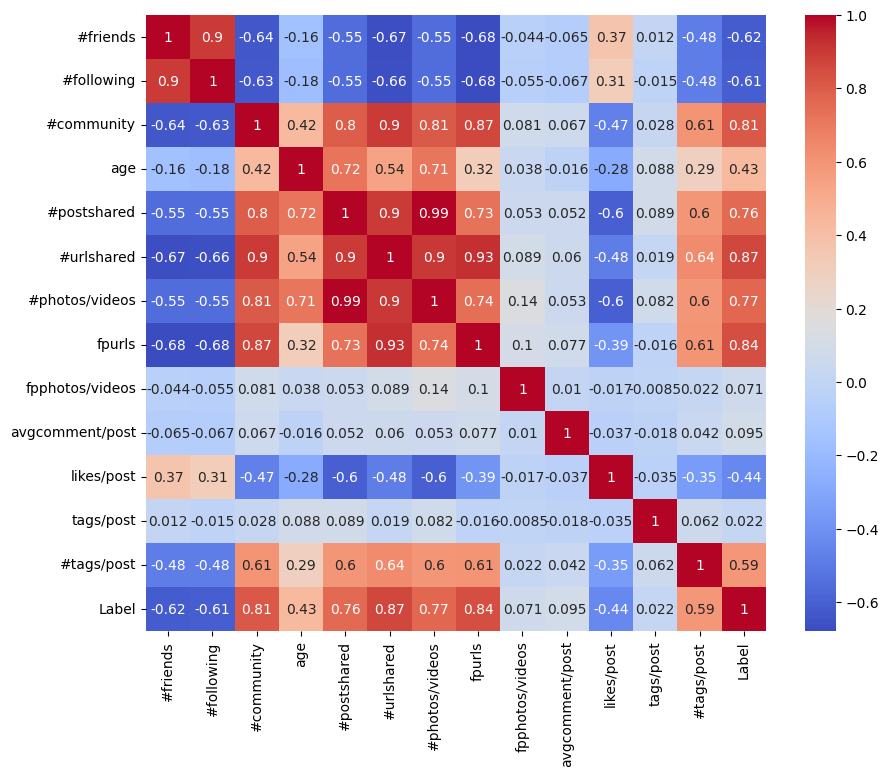

In [38]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [39]:
X = df.drop("Label", axis=1)
y = df["Label"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Logistic Regression

In [42]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [43]:
lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9583333333333334


In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, lr_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        99
           1       0.83      0.95      0.89        21

    accuracy                           0.96       120
   macro avg       0.91      0.96      0.93       120
weighted avg       0.96      0.96      0.96       120



Random Forest

In [44]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [45]:
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9583333333333334


In [48]:
print("Random Forest")
print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        99
           1       0.83      0.95      0.89        21

    accuracy                           0.96       120
   macro avg       0.91      0.96      0.93       120
weighted avg       0.96      0.96      0.96       120



XGBoost


In [46]:
xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.9583333333333334


In [49]:
print("XGBoost")
print(classification_report(y_test, xgb_pred))

XGBoost
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        99
           1       0.83      0.95      0.89        21

    accuracy                           0.96       120
   macro avg       0.91      0.96      0.93       120
weighted avg       0.96      0.96      0.96       120

